In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import os,json,pandas as pd,numpy as np,matplotlib.pyplot as plt,torch,gpytorch
import thermoift.PLOT_SETTINGS as ps
from matplotlib.ticker import AutoMinorLocator
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score as _r2, mean_squared_error as _mse, mean_absolute_error as _mae
from thermoift import MLPostprocessing, MLPreprocessing
from thermoift.rng_utils import get_rng
from thermoift import plot_correlation_heatmap, print_model_metrics
from sklearn.preprocessing import QuantileTransformer
from scipy.spatial import Delaunay
from sklearn.neighbors import NearestNeighbors

# CPU parallelisation — read SLURM_CPUS_PER_TASK if available, else use all cores
_n_cpu = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
torch.set_num_threads(_n_cpu)
torch.set_num_interop_threads(max(1, _n_cpu // 8))

print(f"PyTorch  : {torch.__version__}  (intra-op threads: {torch.get_num_threads()}, interop: {torch.get_num_interop_threads()})")
print(f"GPyTorch : {gpytorch.__version__}")
print(f"CPUs     : {_n_cpu}")

PyTorch  : 2.10.0+cpu  (intra-op threads: 24, interop: 3)
GPyTorch : 1.15.2
CPUs     : 24


In [2]:
class SVGPModel(gpytorch.models.ApproximateGP):
    """Stochastic Variational GP with ARD Matern-5/2 kernel."""

    def __init__(self, inducing_points: torch.Tensor):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )
        super().__init__(variational_strategy)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=inducing_points.shape[1])
        )

    def forward(self, x: torch.Tensor) -> gpytorch.distributions.MultivariateNormal:
        mean_x  = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def init_inducing_points(X_scaled: np.ndarray, n_inducing: int, seed: int,
                         y_raw: np.ndarray | None = None,
                         tail_frac: float = 0.30,
                         tail_threshold: float = 0.3,
                         extreme_frac: float = 0.10,
                         extreme_percentile: float = 99.5) -> torch.Tensor:
    """Three-tier stratified inducing point initialisation.

    Tier 1 — bulk    : k-means centroids for dense-region coverage.
    Tier 2 — mid-tail: random draw from TAIL_THRESHOLD < |y| < extreme_thresh.
    Tier 3 — extreme : random draw from top extreme_percentile % of |y|.
    """
    rng = np.random.default_rng(seed)

    n_extreme = max(1, int(round(n_inducing * extreme_frac)))
    n_tail    = max(1, int(round(n_inducing * tail_frac)))
    n_bulk    = n_inducing - n_tail - n_extreme

    # Tier 1: k-means centroids
    km = MiniBatchKMeans(n_clusters=n_bulk, random_state=seed, n_init=3, batch_size=4096)
    km.fit(X_scaled)
    bulk_pts = km.cluster_centers_

    if y_raw is not None:
        abs_y          = np.abs(y_raw)
        extreme_thresh = np.percentile(abs_y, extreme_percentile)
        et_str         = f"{extreme_thresh:.3f}"

        # Tier 3: top 0.5 % of |residual|
        extreme_mask = abs_y >= extreme_thresh
        n_ext_avail  = int(extreme_mask.sum())
        if n_ext_avail >= n_extreme:
            ext_idx = rng.choice(np.where(extreme_mask)[0], size=n_extreme, replace=False)
        else:
            ext_idx = rng.choice(len(X_scaled), size=n_extreme, replace=False)
            print(f"  [warn] only {n_ext_avail} extreme-tail samples; falling back to random draw")
        extreme_pts = X_scaled[ext_idx]

        # Tier 2: mid-tail (tail_threshold < |y| < extreme_thresh)
        tail_mask    = (abs_y > tail_threshold) & ~extreme_mask
        n_tail_avail = int(tail_mask.sum())
        if n_tail_avail >= n_tail:
            tail_idx = rng.choice(np.where(tail_mask)[0], size=n_tail, replace=False)
        else:
            tail_idx = rng.choice(len(X_scaled), size=n_tail, replace=False)
            print(f"  [warn] only {n_tail_avail} mid-tail samples; falling back to random draw")
        tail_pts = X_scaled[tail_idx]
    else:
        ext_idx     = rng.choice(len(X_scaled), size=n_extreme, replace=False)
        tail_idx    = rng.choice(len(X_scaled), size=n_tail,    replace=False)
        extreme_pts = X_scaled[ext_idx]
        tail_pts    = X_scaled[tail_idx]
        et_str      = "N/A"

    all_pts = np.vstack([bulk_pts, tail_pts, extreme_pts]).astype(np.float32)
    print(f"  Inducing pts: {n_bulk} bulk + {n_tail} mid-tail (|y|>{tail_threshold}) "
          f"+ {n_extreme} extreme (top {100-extreme_percentile:.1f}%, |y|>={et_str}) "
          f"= {len(all_pts)} total")
    return torch.tensor(all_pts, dtype=torch.float32)


def predict_batched(model, likelihood, X_tensor: torch.Tensor,
                    batch_size: int = 2048) -> tuple[np.ndarray, np.ndarray]:
    """Batched prediction to avoid OOM on large datasets."""
    model.eval()
    likelihood.eval()
    means, stds = [], []
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(X_tensor), batch_size):
            xb   = X_tensor[i : i + batch_size]
            pred = likelihood(model(xb))
            means.append(pred.mean.numpy())
            stds.append(pred.stddev.numpy())
    return np.concatenate(means), np.concatenate(stds)


print("SVGPModel, three-tier init_inducing_points, and predict_batched defined.")

# Step 2: invert QuantileTransformer --> original mN/m units
def qt_inverse(arr):
    return qt.inverse_transform(arr.reshape(-1, 1)).ravel()

# Step 3: propagate std via numerical Jacobian of QT inverse
eps = 1e-4
def qt_jacobian(arr):
    return np.abs(qt_inverse(arr + eps) - qt_inverse(arr - eps)) / (2 * eps)

class SVGPWrapper:
    """Thin sklearn-style wrapper so MLPostprocessing.plot_response_curves works unchanged."""
    def __init__(self, model, likelihood, scaler, y_mean, y_std):
        self._model      = model
        self._likelihood = likelihood
        self._scaler     = scaler
        self._y_mean     = y_mean
        self._y_std      = y_std

    def predict(self, X, return_std=False):
        if not isinstance(X, np.ndarray):
            X = np.asarray(X, dtype=np.float32)
        Xs  = self._scaler.transform(X).astype(np.float32)
        Xt  = torch.from_numpy(Xs)
        m, s = predict_batched(self._model, self._likelihood, Xt)
        m_orig = m * self._y_std + self._y_mean
        s_orig = s * self._y_std
        return (m_orig, s_orig) if return_std else m_orig

SVGPModel, three-tier init_inducing_points, and predict_batched defined.


In [3]:
OUTPUT_FOLDER    = "SVGP_RESIDUAL_OUTPUTS"
SEED             = 4555525

# SVGP hyperparameters
N_INDUCING       = 2000   # total inducing points
N_INDUCING_TAIL  = 0.30   # fraction from mid-tail (TAIL_THRESHOLD < |y| < extreme percentile)
N_EXTREME_TAIL   = 0.10   # fraction from extreme tail (top 0.5 % of |residual|)
TAIL_THRESHOLD   = 0.3    # |residual| threshold (mN/m) — lowered from 0.5 to catch more tail
TAIL_OVERSAMPLE  = 5      # mini-batch weight for tail samples
N_EPOCHS         = 500     # training epochs
BATCH_SIZE       = 1024   # mini-batch size
LR               = 0.01   # initial Adam LR (cosine-annealed to LR_MIN)
LR_MIN           = 1e-4   # final LR

# Cross-validation settings
RUN_CV          = False
CV_FOLDS        = 5
CV_EPOCHS       = 30

In [4]:
df          = pd.read_csv("../CombinedDatasetSEC_A4.csv")
df.columns  = [col.strip().replace(" ", "_") for col in df.columns]

# Keep only rows needed to calculate gamma_cDFT and residual
df = df.dropna(subset=["gamma_wsd","gamma_cDFT_minus_wsd_uncorrected","gamma_wsd_UC"]).copy()

# Recalculate gamma_cDFT
df["gamma_cDFT_UC"] = df["gamma_wsd_UC"] + df["gamma_cDFT_minus_wsd_uncorrected"]
df["gamma_cDFT"]    = df["gamma_wsd"]    + df["gamma_cDFT_minus_wsd_corrected"]

# Residual
df["residual"]   = df["gamma_cDFT_UC"] - df["gamma_wsd_UC"]

tol = 1e-10
# Check gamma_cDFT_UC vs gamma_cDFT
diff_gamma = df["gamma_cDFT_UC"] - df["gamma_cDFT"]
mask_gamma = diff_gamma.abs() > tol

if mask_gamma.any():
    print(f"WARNING: {mask_gamma.sum()} rows have mismatched gamma_cDFT values.")

    print(df.loc[mask_gamma, [
        "source_id",
        "gamma_cDFT_UC",
        "gamma_cDFT"]].assign(difference=diff_gamma[mask_gamma]))
else:
    print("All gamma_cDFT values match within tolerance.")

All gamma_cDFT values match within tolerance.


In [5]:
target          = "residual"
rng             = get_rng(seed=SEED)

z_columns       = [col for col in df.columns if col.startswith("z_")]
DROP_FEATURES   = ["z_oxygen"]
Z_non_zero      = [col for col in z_columns if (df[col] != 0).any() and col not in DROP_FEATURES]
features        = ["T", "P"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test,  X_val,  y_test,  y_val  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['T', 'P', 'z_argon', 'z_carbon_dioxide', 'z_carbon_monoxide', 'z_hydrogen', 'z_hydrogen_sulfide', 'z_methane', 'z_nitrogen']

Training samples: 16130
Testing samples:    3456
Validation samples: 3457


Feature correlations with residual:
T                     0.534324
z_carbon_dioxide      0.297844
z_hydrogen_sulfide    0.021386
z_methane            -0.005823
z_carbon_monoxide    -0.037257
P                    -0.061996
z_argon              -0.097609
z_nitrogen           -0.163997
z_hydrogen           -0.184919
Name: residual, dtype: float64


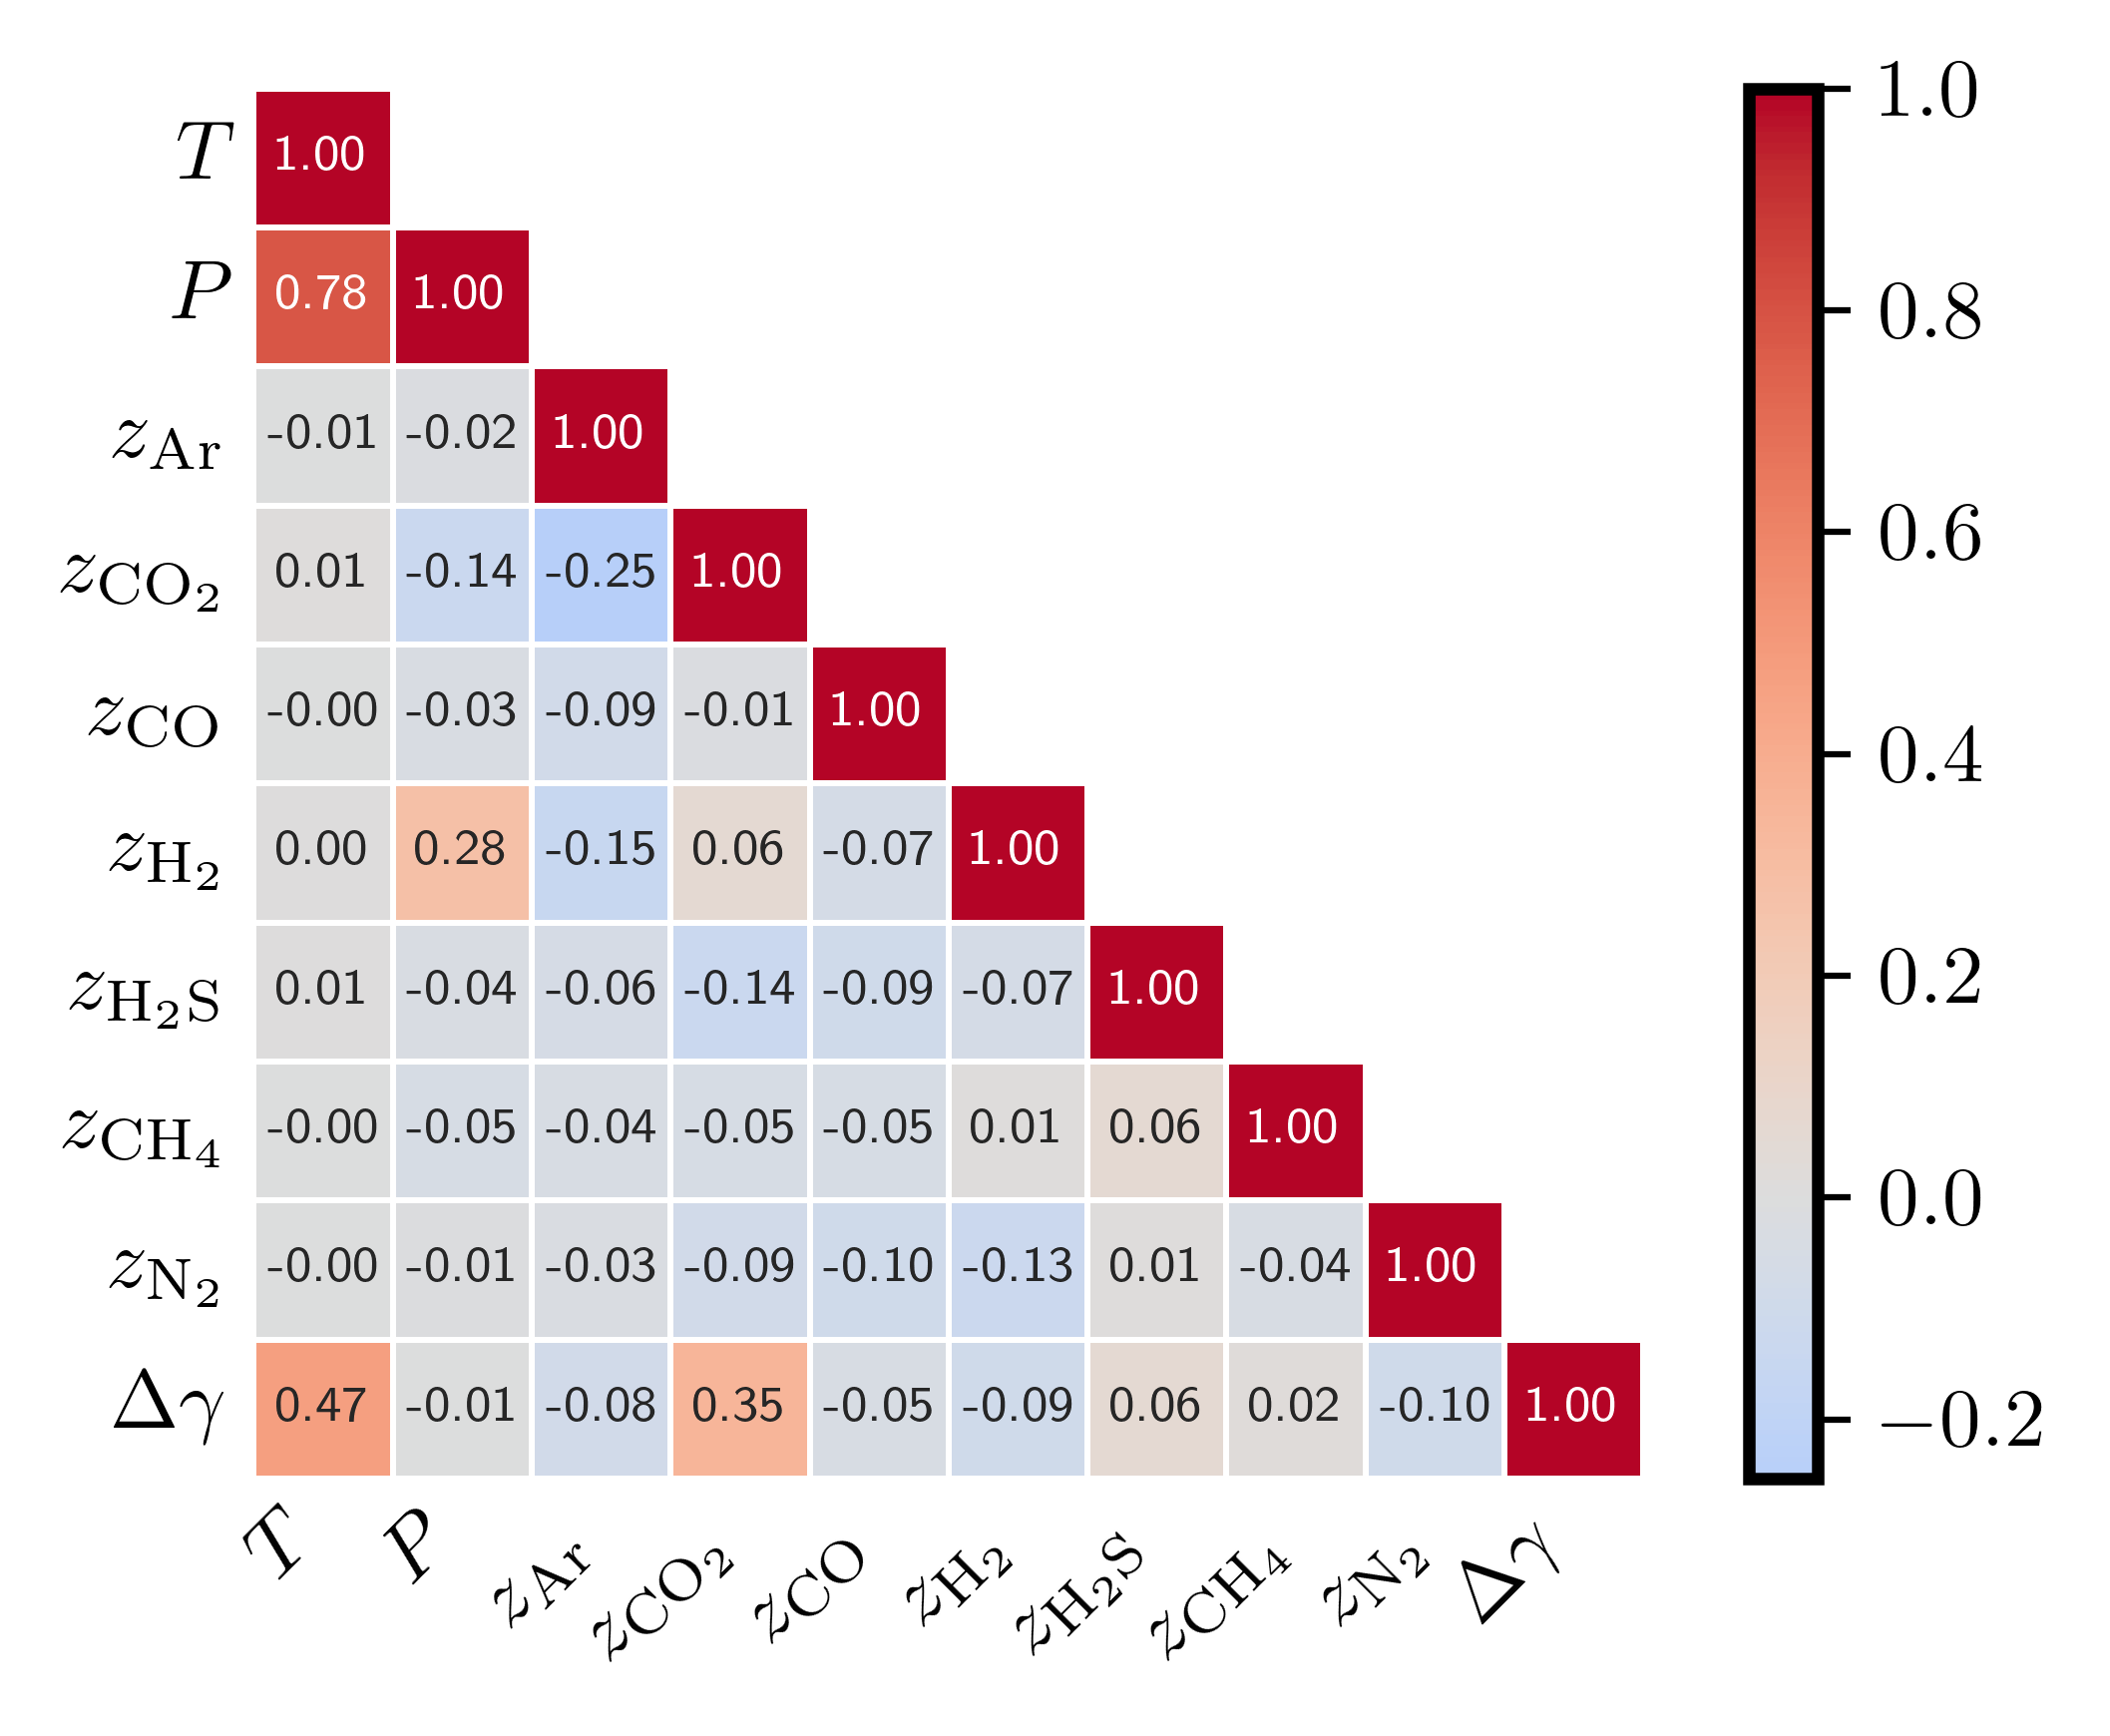

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="SVGP_residual_correlation", folder=OUTPUT_FOLDER)

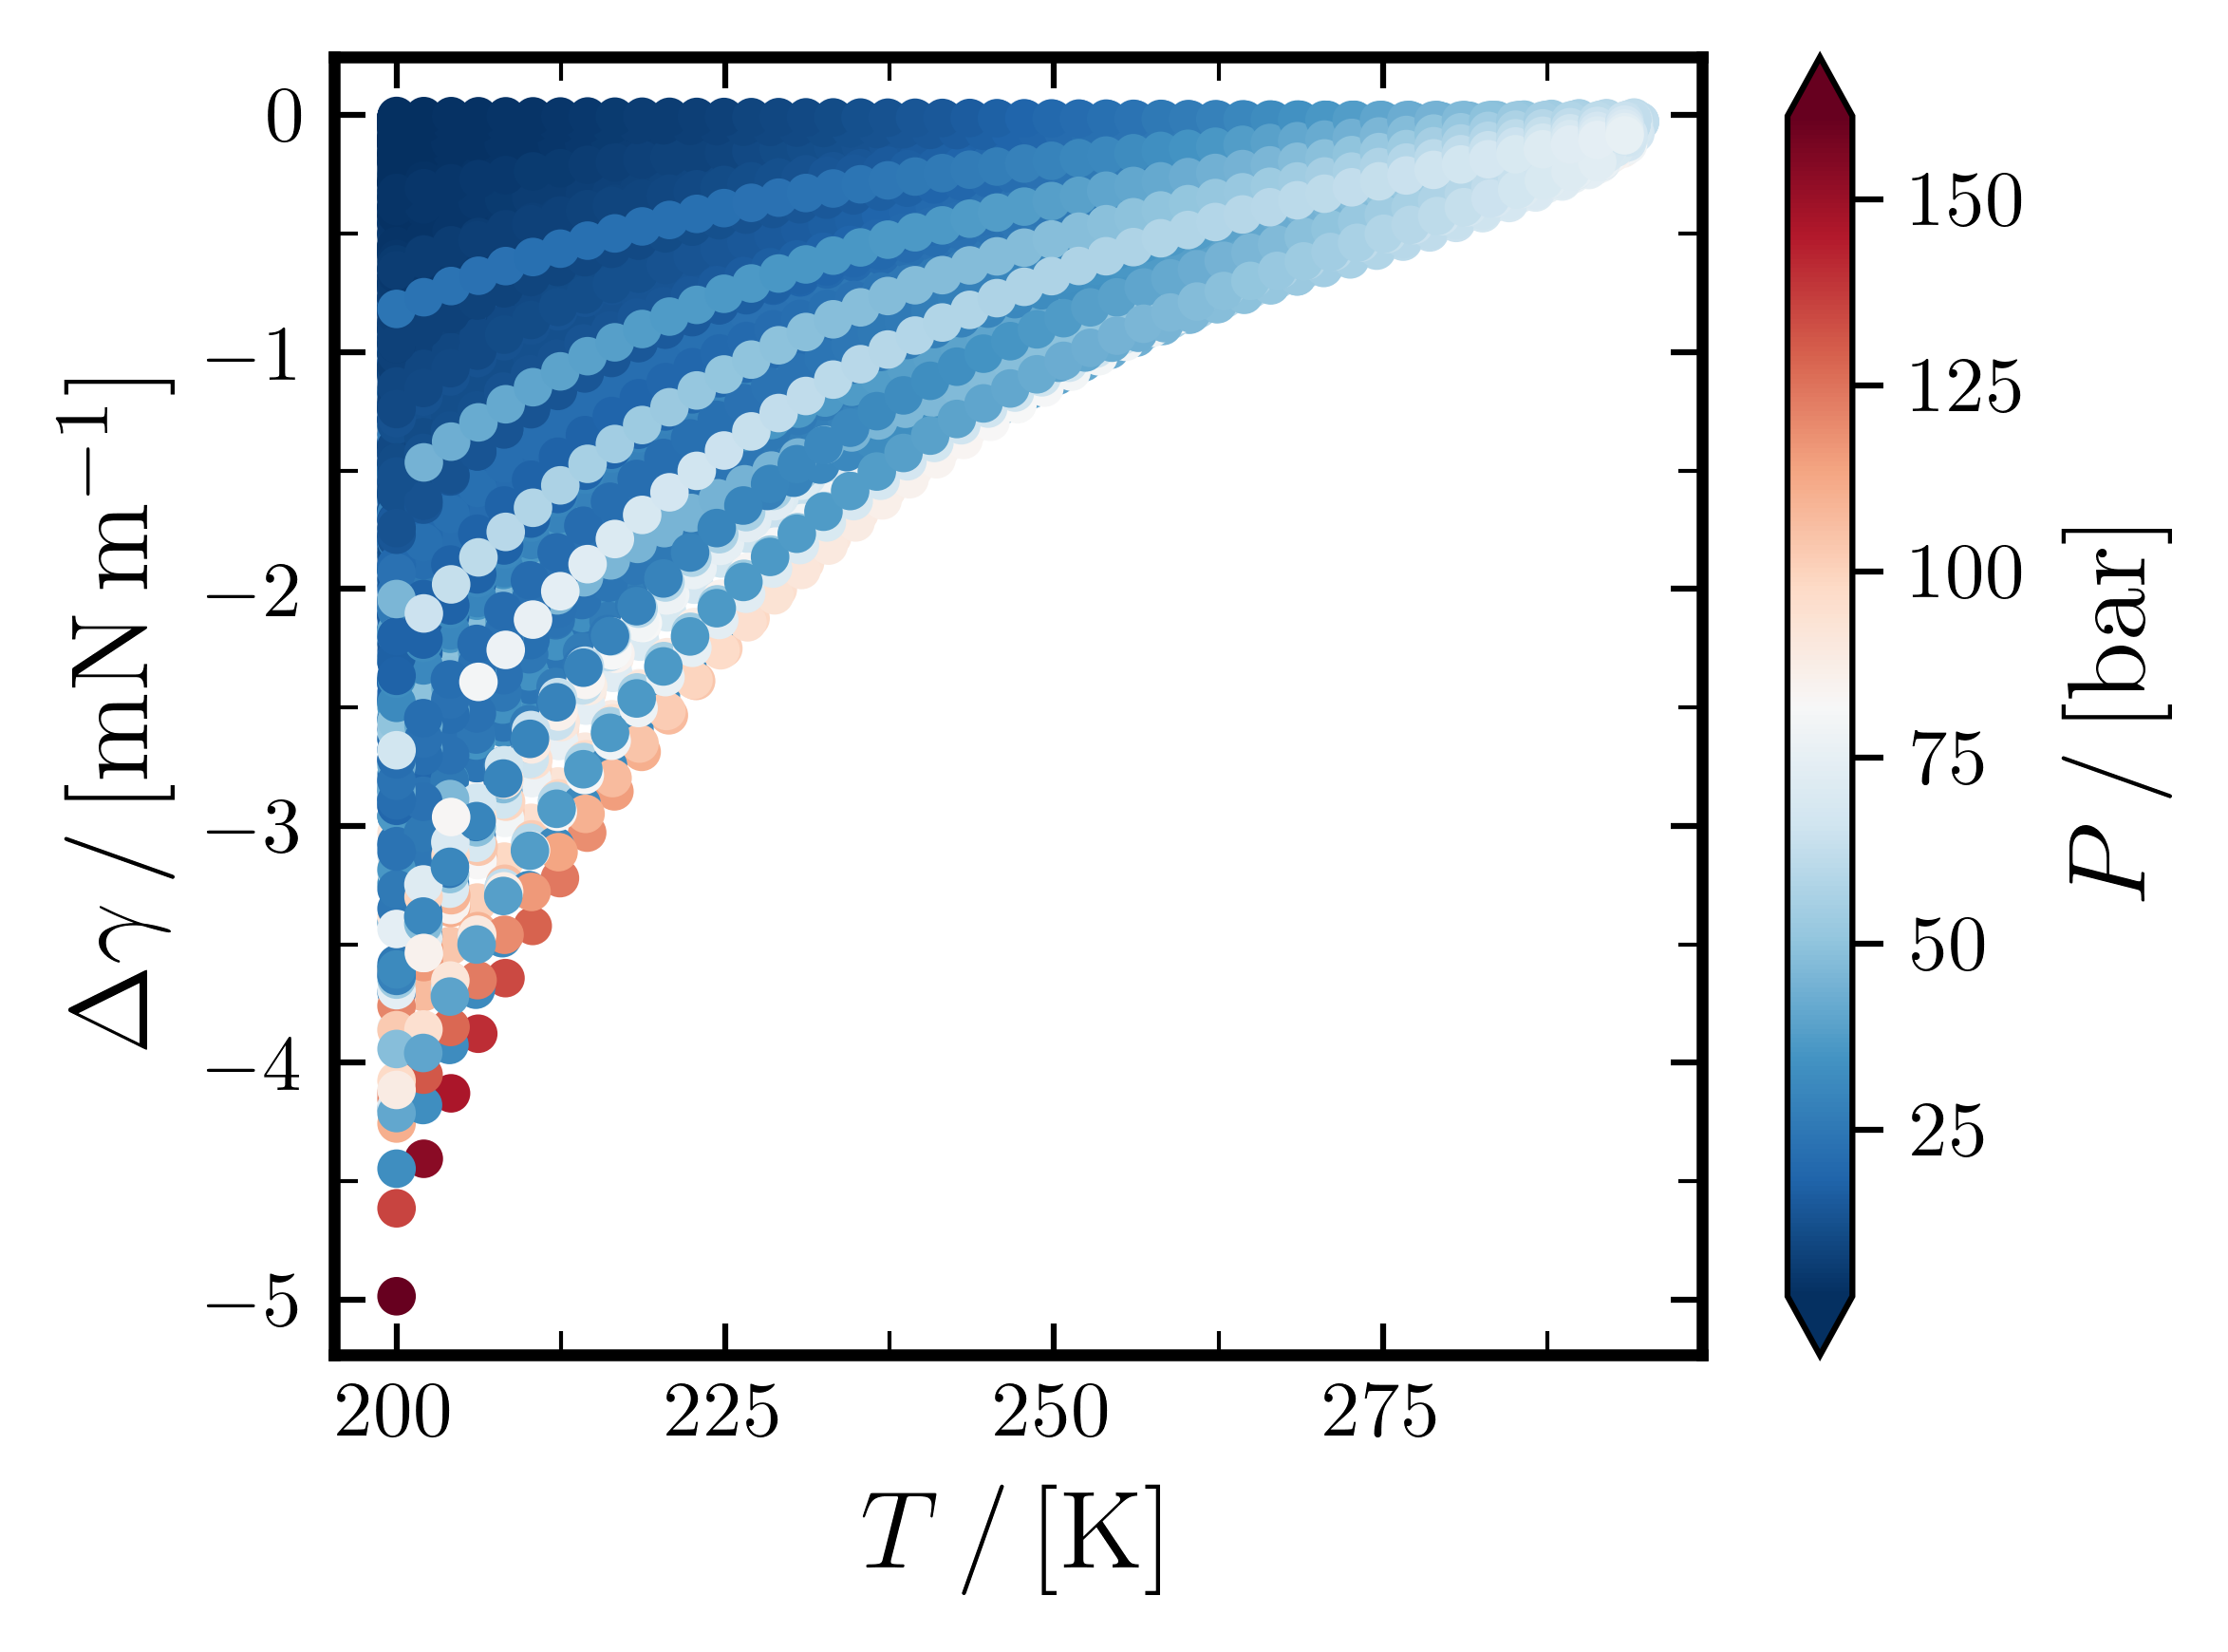

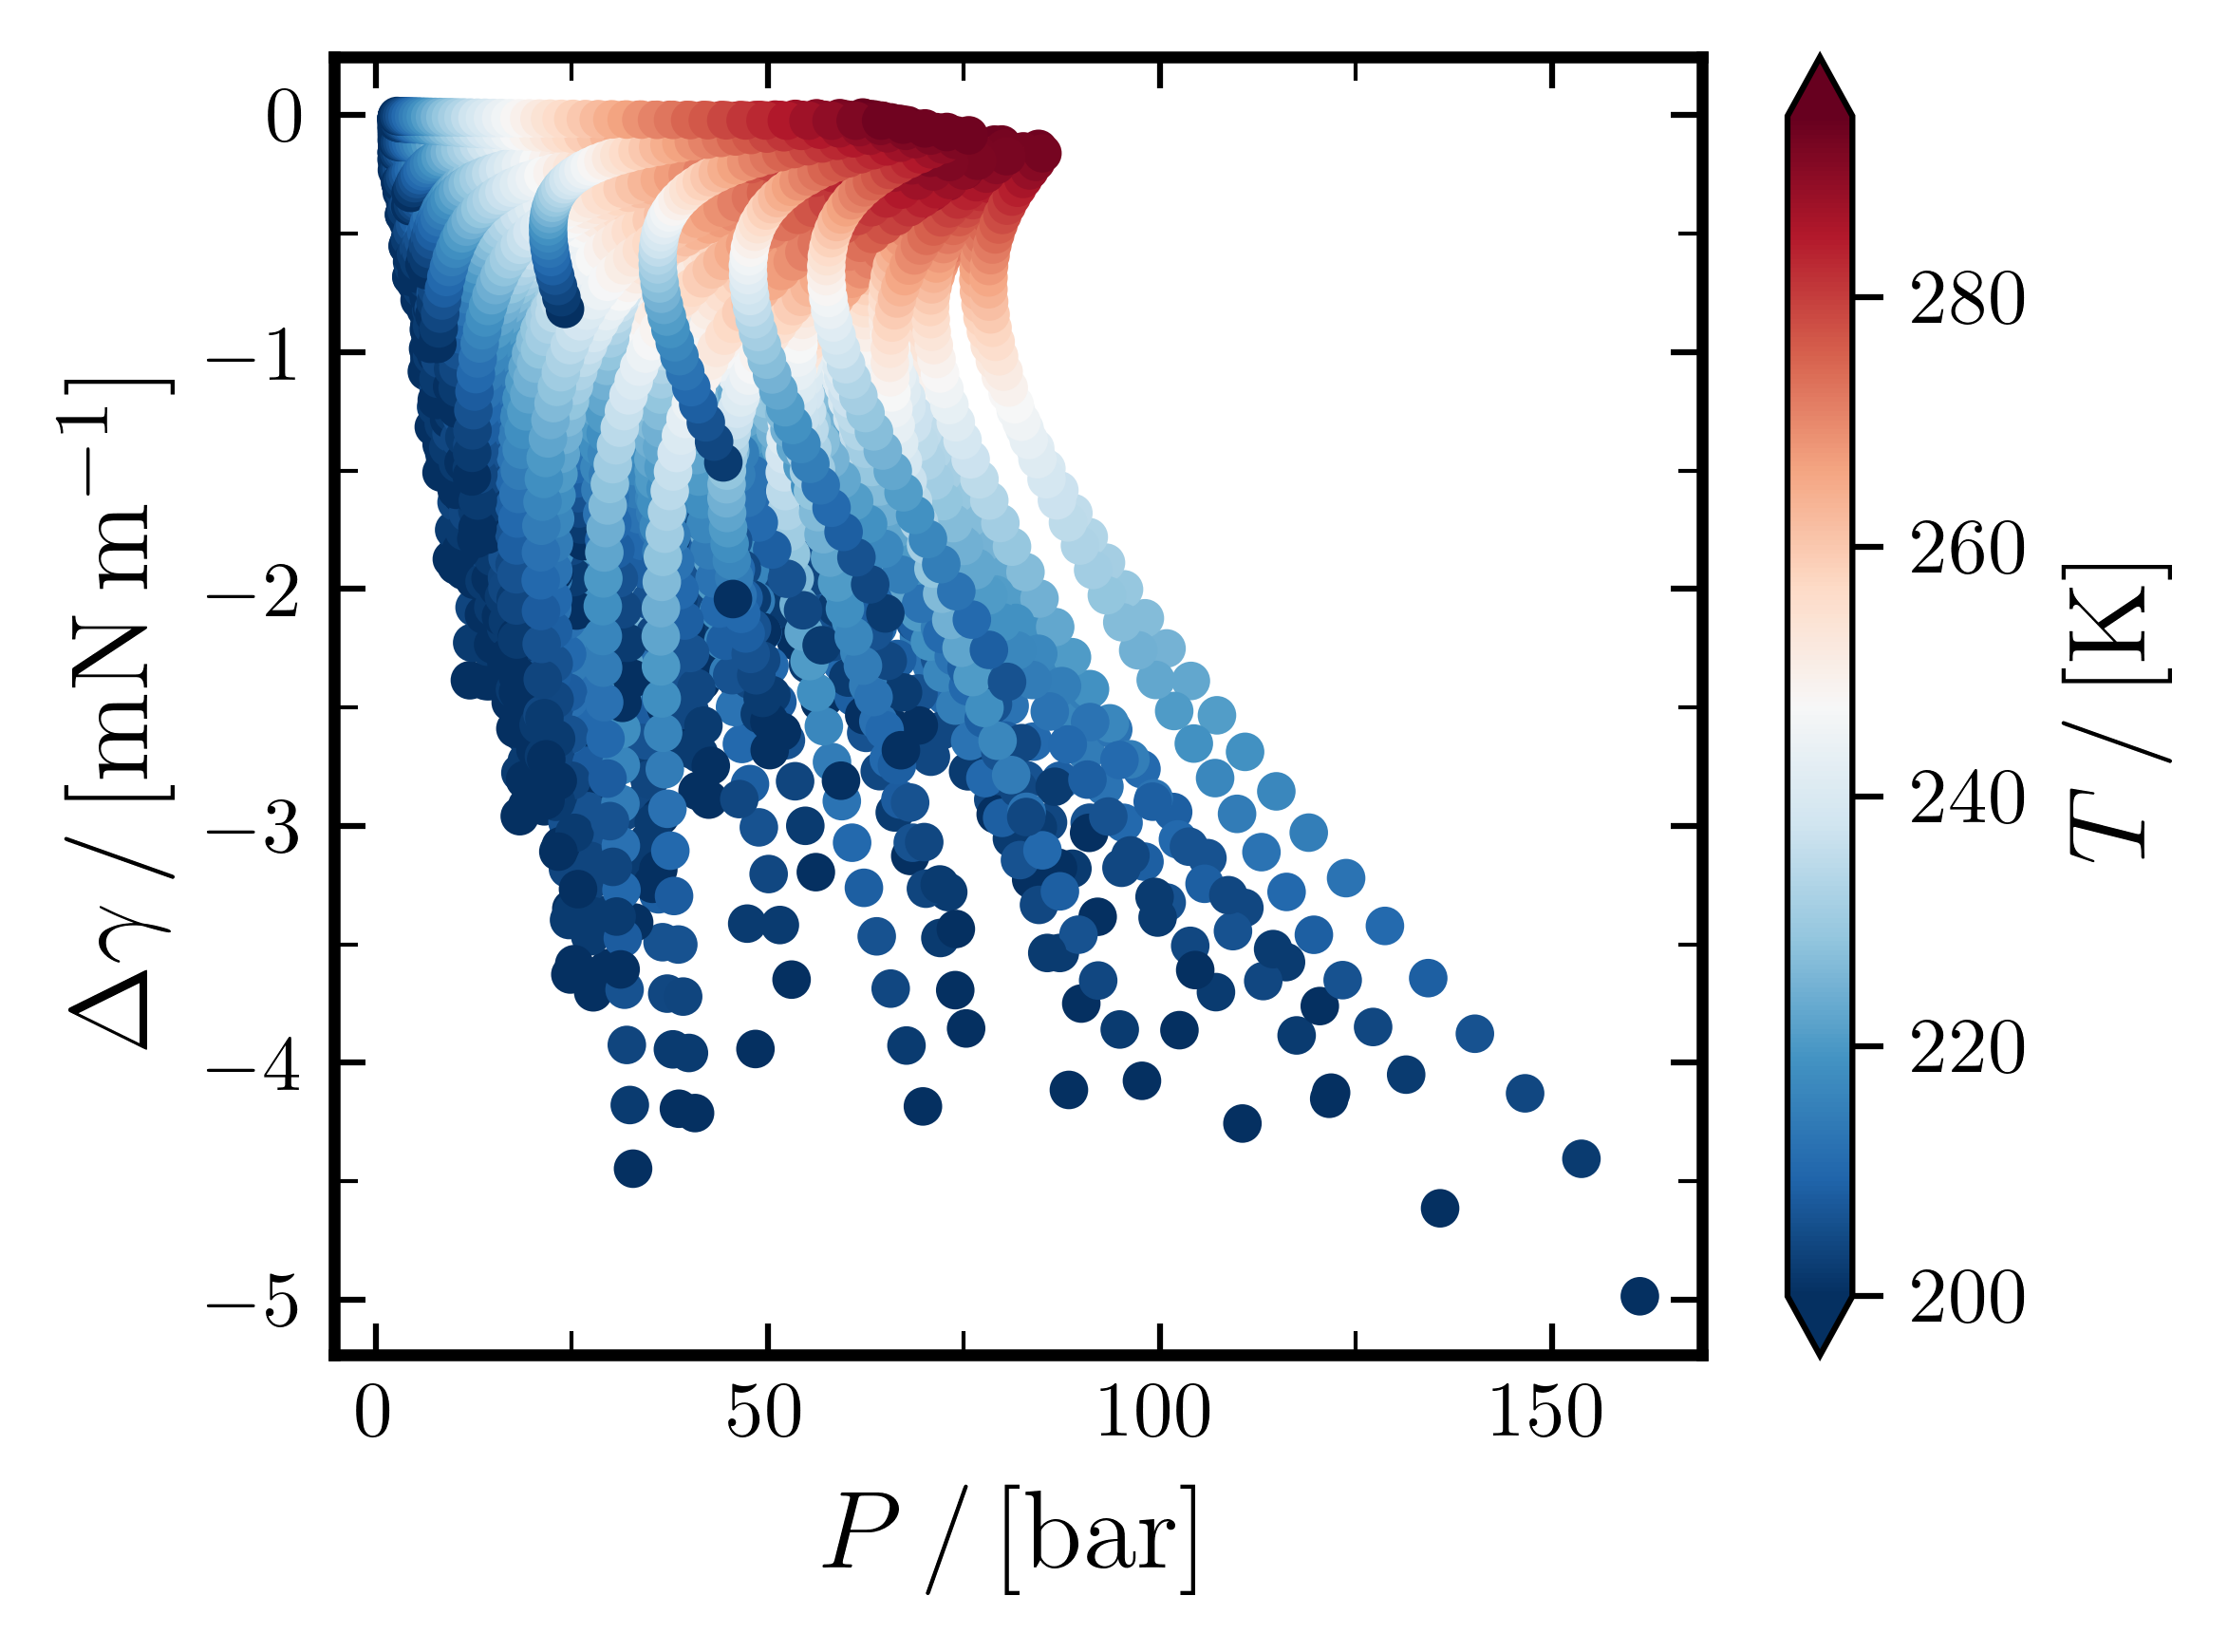

In [8]:
prep = MLPreprocessing(df=df, features=features, target=target)

fig_T, ax_T = prep.plot_scatter(x="T", y=target, color_by="P", cmap="RdBu_r", alpha=1.0)
ax_T.axhline(0.0, color="black", linestyle=":", linewidth=1.0)
ps.save_plot(fig_T, "SVGP_residual_vs_T", folder=OUTPUT_FOLDER)

fig_P, ax_P = prep.plot_scatter(x="P", y=target, color_by="T", cmap="RdBu_r", alpha=1.0)
ax_P.axhline(0.0, color="black", linestyle=":", linewidth=1.0)
ps.save_plot(fig_P, "SVGP_residual_vs_P", folder=OUTPUT_FOLDER)

In [ ]:
df["gamma_base"] = df["gamma_wsd_UC"]

print(df[["gamma_cDFT", "gamma_base", "residual"]].isna().sum())
print("Any NaN in X:", X.isna().any().any())
print("Any NaN in y:", y.isna().any())

In [ ]:
# ── QuantileTransformer target transform ─────────────────────────────────────
# Maps the empirical CDF of y_train to N(0,1): every quantile contributes
# equally to the ELBO, so the sparse positive tail is no longer outweighed
# by the dense negative bulk.  Fit on train only; transform test/val.

qt = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=min(len(y_train), 1000),
    random_state=SEED)

y_train_qt      = qt.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_qt       = qt.transform(y_test.values.reshape(-1, 1)).ravel()
y_val_qt        = qt.transform(y_val.values.reshape(-1, 1)).ravel()

# StandardScaler on top (keeps pipeline consistent; ≈ no-op since QT --> N(0,1))
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled   = scaler.transform(X_test).astype(np.float32)
X_val_scaled    = scaler.transform(X_val).astype(np.float32)
X_all_scaled    = scaler.transform(X).astype(np.float32)

y_mean_val      = float(y_train_qt.mean())
y_std_val       = float(y_train_qt.std())

y_train_norm    = ((y_train_qt - y_mean_val) / y_std_val).astype(np.float32)
y_test_norm     = ((y_test_qt  - y_mean_val) / y_std_val).astype(np.float32)
y_val_norm      = ((y_val_qt   - y_mean_val) / y_std_val).astype(np.float32)

# Tensors
X_train_tensor = torch.from_numpy(X_train_scaled)
X_test_tensor  = torch.from_numpy(X_test_scaled)
X_val_tensor   = torch.from_numpy(X_val_scaled)
y_train_tensor = torch.from_numpy(y_train_norm)

print(f"X_train tensor: {X_train_tensor.shape}  dtype: {X_train_tensor.dtype}")
print(f"y QT normalisation — mean: {y_mean_val:.4f}  std: {y_std_val:.4f}")


In [ ]:
# Three-tier stratified inducing points
inducing_points = init_inducing_points(
    X_train_scaled, N_INDUCING, SEED,
    y_raw        = y_train.values,
    tail_frac    = N_INDUCING_TAIL,
    tail_threshold = TAIL_THRESHOLD,
    extreme_frac = N_EXTREME_TAIL,
    extreme_percentile = 99.5,
)
print(f"Inducing points shape: {inducing_points.shape}")

# Build model and likelihood
torch.manual_seed(SEED)
svgp_model = SVGPModel(inducing_points)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

# ELBO objective
mll = gpytorch.mlls.VariationalELBO(likelihood, svgp_model, num_data=len(X_train_tensor))

# Optimizer — joint over model + likelihood parameters
optimizer = torch.optim.Adam(
    list(svgp_model.parameters()) + list(likelihood.parameters()),
    lr=LR)

# Cosine annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=LR_MIN)

# ── Weighted DataLoader — two-level oversampling ──────────────────────────────
# Extreme tail (top 0.5 %) gets 3× TAIL_OVERSAMPLE; mid-tail gets TAIL_OVERSAMPLE; bulk gets 1.
y_train_abs    = np.abs(y_train.values)
extreme_thresh = np.percentile(y_train_abs, 99.5)
sample_weights = np.where(
    y_train_abs >= extreme_thresh,
    float(TAIL_OVERSAMPLE) * 3.0,
    np.where(y_train_abs > TAIL_THRESHOLD, float(TAIL_OVERSAMPLE), 1.0)
).astype(np.float32)

sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader — parallel workers for data prefetching
_n_workers = min(int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1)), 16)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=_n_workers,
    persistent_workers=(_n_workers > 0),
    prefetch_factor=2 if _n_workers > 0 else None,
)

n_extreme_samples = int((y_train_abs >= extreme_thresh).sum())
n_tail_samples    = int(((y_train_abs > TAIL_THRESHOLD) & (y_train_abs < extreme_thresh)).sum())
print(f"Extreme-tail samples (top 0.5%, |y|≥{extreme_thresh:.3f}): {n_extreme_samples}")
print(f"Mid-tail samples    (|y|>{TAIL_THRESHOLD}):                 {n_tail_samples}")
print(f"DataLoader workers: {_n_workers}")

total_params = sum(p.numel() for p in svgp_model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Batches per epoch: {len(train_loader)}")

In [ ]:
svgp_model.train()
likelihood.train()

losses = []
train_start = time.perf_counter()

for epoch in range(1, N_EPOCHS + 1):
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = svgp_model(x_batch)
        loss   = -mll(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()  # cosine LR decay
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if epoch % 10 == 0 or epoch == 1:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | ELBO loss: {avg_loss:.4f} | LR: {current_lr:.2e}")

train_elapsed = time.perf_counter() - train_start
print(f"\nTraining time: {train_elapsed/60:.2f} min")

In [ ]:
# ELBO loss curve — styled with PLOT_SETTINGS
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(range(1, len(losses) + 1), losses,
        color=ps.colors[2], linewidth=ps.linewidth, label="Negative ELBO")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"Negative ELBO loss")
ax.xaxis.set_minor_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ps.style_legend(ax, loc="upper right")
plt.tight_layout()
ps.save_plot(fig, "SVGP_training_loss", folder=OUTPUT_FOLDER)
plt.show()

In [ ]:
# Batched predictions — undo StandardScaler then invert QuantileTransformer
y_train_pred_norm, y_train_std_norm = predict_batched(svgp_model, likelihood, X_train_tensor)
y_test_pred_norm,  y_test_std_norm  = predict_batched(svgp_model, likelihood, X_test_tensor)
y_val_pred_norm,   y_val_std_norm   = predict_batched(svgp_model, likelihood, X_val_tensor)

# Step 1: undo StandardScaler (back to QT-transformed space)
y_train_pred_qt = y_train_pred_norm * y_std_val + y_mean_val
y_test_pred_qt  = y_test_pred_norm  * y_std_val + y_mean_val
y_val_pred_qt   = y_val_pred_norm   * y_std_val + y_mean_val

# Step 2: invert QuantileTransformer --> original mN/m units
y_train_pred = qt_inverse(y_train_pred_qt)
y_test_pred  = qt_inverse(y_test_pred_qt)
y_val_pred   = qt_inverse(y_val_pred_qt)

# Step 3: propagate std via numerical Jacobian of QT inverse
# dy_orig/dy_qt ≈ [QT^{-1}(y+ε) - QT^{-1}(y-ε)] / (2ε)
y_train_std = y_train_std_norm * y_std_val * qt_jacobian(y_train_pred_qt)
y_test_std  = y_test_std_norm  * y_std_val * qt_jacobian(y_test_pred_qt)
y_val_std   = y_val_std_norm   * y_std_val * qt_jacobian(y_val_pred_qt)

# Metrics
metrics = print_model_metrics(
    y_train, y_train_pred,
    y_test,  y_test_pred,
    target,  unit="mN/m",
    y_val=y_val, y_val_pred=y_val_pred,
)
metrics["train_mae_mNm"] = float(_mae(y_train, y_train_pred))
metrics["test_mae_mNm"]  = float(_mae(y_test,  y_test_pred))
metrics["val_mae_mNm"]   = float(_mae(y_val,   y_val_pred))

In [ ]:
# ── 1. Rank test set by absolute error ───────────────────────────────────────
test_errors = np.abs(y_test.values - y_test_pred)
n_show      = 10
top_idx     = np.argsort(test_errors)[::-1][:n_show]

outlier_df = X_test.iloc[top_idx].copy()
outlier_df["residual_actual"]    = y_test.values[top_idx]
outlier_df["residual_predicted"] = y_test_pred[top_idx]
outlier_df["pred_std"]           = y_test_std[top_idx]
outlier_df["abs_error"]          = test_errors[top_idx]
outlier_df["source_id"]          = df.loc[X_test.index[top_idx], "source_id"].values

print("Top-10 test outliers:\n")
print(outlier_df[["source_id", "T", "P",
                   "residual_actual", "residual_predicted",
                   "pred_std", "abs_error"]].to_string(index=False))

# ── 2. Nearest-neighbour diagnosis on worst outlier ──────────────────────────
worst_i    = top_idx[0]
worst_feat = X_test_scaled[worst_i : worst_i + 1]

k    = 10
nbrs = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(X_train_scaled)
dists, idxs = nbrs.kneighbors(worst_feat)
nn_residuals = y_train.values[idxs[0]]
nn_dists     = dists[0]

print(f"\n--- Nearest {k} TRAINING neighbours of the worst outlier ---")
print(f"Outlier:  actual={y_test.values[worst_i]:.4f}  predicted={y_test_pred[worst_i]:.4f}  "
      f"abs_error={test_errors[worst_i]:.4f} mN/m\n")
print(f"{'Rank':<5} {'Dist (scaled)':>14} {'Residual actual':>16}   source_id")
for rank, (d, res_idx) in enumerate(zip(nn_dists, idxs[0]), 1):
    sid = df.loc[X_train.index[res_idx], "source_id"]
    print(f"  {rank:<3} {d:>14.4f} {nn_residuals[rank-1]:>16.4f}   {sid}")

nn_mean  = float(nn_residuals.mean())
nn_std   = float(nn_residuals.std())
gap      = abs(float(y_test.values[worst_i]) - nn_mean)
min_dist = float(nn_dists.min())

print(f"\nNeighbour residuals — mean: {nn_mean:.4f}  std: {nn_std:.4f}  "
      f"min: {nn_residuals.min():.4f}  max: {nn_residuals.max():.4f}")
print(f"Nearest neighbour distance (scaled space): {min_dist:.4f}")

# ── 3. Automatic verdict ──────────────────────────────────────────────────────
print("\n=== DIAGNOSIS ===")
if min_dist > 1.5:
    verdict = "ISOLATED"
    print("ISOLATED — nearest training neighbour is far (dist > 1.5).")
    print("  -> GP has no local anchor here. Moving this region into training is the only real fix.")
elif gap > 0.8:
    verdict = "CONFLICT"
    print(f"FEATURE-SPACE CONFLICT — point is near training data but neighbours have very different")
    print(f"  residuals (outlier={y_test.values[worst_i]:.3f}, neighbour mean={nn_mean:.3f}, gap={gap:.3f}).")
    print("  -> Likely a data anomaly — inspect the cDFT calculation for this source_id.")
else:
    verdict = "CAPACITY"
    print("CAPACITY — neighbours are nearby with consistent residuals; model just needs more training.")
    print("  -> More epochs or larger N_INDUCING should close this gap.")

# ── 4. Parity plot with outlier highlighted ───────────────────────────────────
worst_actual = float(y_test.values[worst_i])
worst_pred   = float(y_test_pred[worst_i])
worst_std_v  = float(y_test_std[worst_i])

fig, ax = ps.plot_init(w=5, h=4.5)
ax.scatter(y_test, y_test_pred, s=10, alpha=0.4,
           color=ps.colors[2], edgecolors="none", label="Test set", zorder=2)
ax.errorbar(worst_actual, worst_pred, yerr=2 * worst_std_v,
            fmt="o", color=ps.colors[0], markersize=7, capsize=4,
            label=rf"Outlier ({verdict}, $2\sigma$)", zorder=5)
lims = [min(float(y_test.min()), float(y_test_pred.min())) - 0.2,
        max(float(y_test.max()), float(y_test_pred.max())) + 0.2]
ax.plot(lims, lims, "k--", linewidth=0.8, zorder=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r"Actual $\Delta\gamma$ / [mN m$^{-1}$]")
ax.set_ylabel(r"Predicted $\Delta\gamma$ / [mN m$^{-1}$]")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ps.style_legend(ax, loc="upper left")
plt.tight_layout()
ps.save_plot(fig, "SVGP_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()

In [ ]:
# ARD feature importances: inverse length-scale (same interpretation as GPR)
_length_scales       = svgp_model.covar_module.base_kernel.lengthscale.squeeze().detach().numpy()
_feature_importances = 1.0 / _length_scales
_feature_importances = _feature_importances / _feature_importances.sum()

post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="delta_gamma",
    feature_importances=_feature_importances,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

In [ ]:
post.plot_parity(model_name="SVGP (RBF-ARD)", save_path="SVGP_gamma_parity_plot", folder=OUTPUT_FOLDER)

In [ ]:
post.plot_residual_distribution(save_path="SVGP_gamma_residual_distribution", folder=OUTPUT_FOLDER)

In [ ]:
post.plot_residual_vs_predicted(save_path="SVGP_gamma_residual_vs_predicted", folder=OUTPUT_FOLDER,
                                y_range = (-2, 2))

In [ ]:
post.plot_std_histogram(y_test_std, save_path="SVGP_gamma_std_histogram", folder=OUTPUT_FOLDER)

In [ ]:
post.plot_parity_colored_by_std(y_test_std, save_path="SVGP_gamma_parity_colored_std", folder=OUTPUT_FOLDER)

In [ ]:
post.plot_error_vs_std(y_test_std, save_path="SVGP_gamma_error_vs_std", folder=OUTPUT_FOLDER)

In [ ]:
# # Response curves — wrap the SVGP in a predict-only callable compatible with MLPostprocessing
# svgp_wrapper = SVGPWrapper(svgp_model, likelihood, scaler, y_mean_val, y_std_val)

# X_ref = X_train.median().values
# post.plot_response_curves(
#     model               = svgp_wrapper,
#     X_ref               = X_ref,
#     feature_names       = features,
#     X_train             = X_train,
#     n_points            = 100,
#     return_std          = True,
#     save_individually   = True,
#     save_path           = "SVGP_gamma_response",
#     folder              = OUTPUT_FOLDER,
# )

In [ ]:
# Read data
df = pd.read_csv("../../interfacial_results_dataset_A4.csv")

# Take maximum P_bubble and P_dew at each temperature
df_max = (df.groupby("temperature", as_index=False)[["P_bubble", "P_dew"]].max().sort_values("temperature"))

In [ ]:
# from scipy.spatial import Delaunay
# from scipy.interpolate import interp1d, CloughTocher2DInterpolator, NearestNDInterpolator
# from matplotlib.ticker import AutoMinorLocator
# from matplotlib.path import Path
# from matplotlib.patches import PathPatch

# # =============================================================================
# # 1) Phase envelope: max P_bubble and P_dew at each T (drop last point)
# # =============================================================================
# df_max = (
#     df.groupby("temperature")[["P_bubble", "P_dew"]]
#       .max()
#       .reset_index()
#       .sort_values("temperature")
#       .dropna()
# )
# df_env = df_max.iloc[:-1].copy()

# T_env     = df_env["temperature"].values
# P_bub_env = df_env["P_bubble"].values
# P_dew_env = df_env["P_dew"].values

# bub_interp = interp1d(T_env, P_bub_env, kind="linear", bounds_error=False,
#                       fill_value=(P_bub_env[0], P_bub_env[-1]))
# dew_interp = interp1d(T_env, P_dew_env, kind="linear", bounds_error=False,
#                       fill_value=(P_dew_env[0], P_dew_env[-1]))

# # =============================================================================
# # 2) Coarse prediction grid + valid-domain mask
# # =============================================================================
# T_train = X_train["T"].values
# P_train = X_train["P"].values

# n_grid = 120
# T_vals = np.linspace(T_train.min(), T_train.max(), n_grid)
# P_vals = np.linspace(P_train.min(), P_train.max(), n_grid)
# TT, PP = np.meshgrid(T_vals, P_vals)

# hull    = Delaunay(np.column_stack([T_train, P_train]))
# in_hull = hull.find_simplex(np.column_stack([TT.ravel(), PP.ravel()])) >= 0
# in_env  = (PP.ravel() <= bub_interp(TT.ravel())) & (PP.ravel() >= dew_interp(TT.ravel()))
# mask    = (in_hull & in_env).reshape(n_grid, n_grid)

# # =============================================================================
# # 3) Predict on coarse grid
# # =============================================================================
# T_idx  = features.index("T")
# P_idx  = features.index("P")
# X_ref  = X_train.median().values.copy()
# X_grid = np.tile(X_ref, (n_grid * n_grid, 1))
# X_grid[:, T_idx] = TT.ravel()
# X_grid[:, P_idx] = PP.ravel()

# mean_flat = svgp_wrapper.predict(pd.DataFrame(X_grid, columns=features))
# mean_grid = mean_flat.reshape(n_grid, n_grid).astype(float)
# mean_grid[~mask] = np.nan

# # =============================================================================
# # 4) Smooth field on dense grid via Clough-Tocher
# # =============================================================================
# valid_pts  = np.column_stack([TT[~np.isnan(mean_grid)], PP[~np.isnan(mean_grid)]])
# valid_vals = mean_grid[~np.isnan(mean_grid)]

# ct_interp = CloughTocher2DInterpolator(valid_pts, valid_vals)
# nn_fill   = NearestNDInterpolator(valid_pts, valid_vals)

# n_smooth = 400
# T_vals_s = np.linspace(T_train.min(), T_train.max(), n_smooth)
# P_vals_s = np.linspace(P_train.min(), P_train.max(), n_smooth)
# TT_s, PP_s = np.meshgrid(T_vals_s, P_vals_s)

# in_hull_s = hull.find_simplex(np.column_stack([TT_s.ravel(), PP_s.ravel()])) >= 0
# in_env_s  = (PP_s.ravel() <= bub_interp(TT_s.ravel())) & (PP_s.ravel() >= dew_interp(TT_s.ravel()))
# mask_s    = (in_hull_s & in_env_s).reshape(n_smooth, n_smooth)

# mean_smooth = ct_interp(TT_s, PP_s)
# nan_holes   = np.isnan(mean_smooth)
# mean_smooth[nan_holes] = nn_fill(TT_s[nan_holes], PP_s[nan_holes])
# mean_smooth[~mask_s]   = np.nan

# Z_masked = np.ma.masked_invalid(mean_smooth)

# # =============================================================================
# # 5) Asymmetric, data-driven colour limits
# # =============================================================================
# vmin = float(np.nanpercentile(mean_smooth,  1.0))
# vmax = float(np.nanpercentile(mean_smooth, 99.0))

# line_levels = np.linspace(vmin, vmax, 9)

# # =============================================================================
# # 6) Envelope clip polygon — built from interpolators on the FULL T-grid
# #    so there is no gap at low T where T_env doesn't reach.
# # =============================================================================
# clip_T_seq = T_vals_s
# clip_P_top = bub_interp(clip_T_seq)
# clip_P_bot = dew_interp(clip_T_seq)

# clip_T = np.concatenate([clip_T_seq, clip_T_seq[::-1]])
# clip_P = np.concatenate([clip_P_top, clip_P_bot[::-1]])
# clip_verts = np.column_stack([clip_T, clip_P])
# clip_path  = Path(clip_verts, closed=True)


# def _apply_clip(artist, patch):
#     """Clip artists across matplotlib versions."""
#     try:
#         artist.set_clip_path(patch)
#     except AttributeError:
#         for coll in getattr(artist, "collections", []):
#             coll.set_clip_path(patch)

# # =============================================================================
# # 7) Plot
# # =============================================================================
# fig, ax = ps.plot_init(w=6, h=4.5)

# clip_patch = PathPatch(clip_path, facecolor="none", edgecolor="none",
#                        transform=ax.transData)
# ax.add_patch(clip_patch)

# # Continuous filled surface via pcolormesh (no discrete colourbar steps)
# pcm = ax.pcolormesh(
#     TT_s, PP_s, Z_masked,
#     cmap="Blues_r",
#     vmin=vmin, vmax=vmax,
#     shading="gouraud",
#     zorder=1,
# )
# _apply_clip(pcm, clip_patch)

# # Tiny grey training-data markers
# ax.scatter(
#     T_train, P_train,
#     color="0.35",
#     s=1.5,
#     alpha=0.35,
#     linewidths=0,
#     zorder=3,
# )

# # Isolines on top of the smooth fill, also clipped
# cs = ax.contour(
#     TT_s, PP_s, Z_masked,
#     levels=line_levels,
#     colors="black",
#     linewidths=0.55,
#     linestyles="solid",
#     corner_mask=True,
#     zorder=6,
# )
# _apply_clip(cs, clip_patch)

# ax.clabel(cs, inline=True, inline_spacing=3,
#           fontsize=ps.label_fontsize * 0.65, fmt="%.2g")

# # Phase envelope curves
# ax.plot(T_env, P_bub_env, "o-", color=ps.colors[0],
#         linewidth=ps.linewidth, markersize=ps.markersize,
#         label=r"max $P_{\mathrm{bubble}}$", zorder=7)
# ax.plot(T_env, P_dew_env, "s-", color=ps.colors[1],
#         linewidth=ps.linewidth, markersize=ps.markersize,
#         label=r"max $P_{\mathrm{dew}}$", zorder=7)

# # Continuous colorbar driven by pcolormesh
# cbar = fig.colorbar(pcm, ax=ax, pad=0.02, extend="both")
# cbar.set_label(r"$\langle\Delta\gamma\rangle$ / [mN m$^{-1}$]",
#                fontsize=ps.label_fontsize)
# ps.style_colorbar(cbar)

# # Axes
# ax.set_xlabel(r"$T$ / [K]", fontsize=ps.label_fontsize)
# ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.set_xlim(T_train.min(), T_train.max())
# ax.set_ylim(P_train.min(), P_train.max())

# ps.style_legend(ax, loc="upper right")
# plt.tight_layout()
# ps.save_plot(fig, "SVGP_2D_response_T_P", folder=OUTPUT_FOLDER)
# plt.show()

In [ ]:
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

model_state = {
    "model_state_dict":      svgp_model.state_dict(),
    "likelihood_state_dict": likelihood.state_dict(),
    "scaler":                scaler,
    "qt":                    qt,           # QuantileTransformer (replaces signlog)
    "y_mean":                y_mean_val,
    "y_std":                 y_std_val,
    "y_transform":           "quantile_normal",
    "n_inducing":            N_INDUCING,
    "features":              features,
    "target":                target,
}
model_path = os.path.join(OUTPUT_FOLDER, "SVGP_residual_model.pt")
torch.save(model_state, model_path)
print(f"Model saved to: {model_path}")

In [ ]:
# Reconstruct full gamma_cDFT = gamma_base + residual_pred
# NOTE: `df` was reassigned to a different CSV in an earlier cell, so reload
# the original training dataframe here to recover gamma_base / gamma_cDFT.
_df_orig = pd.read_csv("../CombinedDatasetSEC_A4.csv")
_df_orig.columns = [c.strip().replace(" ", "_") for c in _df_orig.columns]
_df_orig = _df_orig.dropna(
    subset=["gamma_wsd", "gamma_cDFT_minus_wsd_uncorrected", "gamma_wsd_UC"]
).copy()
_df_orig["gamma_cDFT"] = _df_orig["gamma_wsd"] + _df_orig["gamma_cDFT_minus_wsd_corrected"]
_df_orig["gamma_base"] = _df_orig["gamma_wsd_UC"]

gamma_base_train = _df_orig.loc[X_train.index, "gamma_base"].values
gamma_base_test  = _df_orig.loc[X_test.index,  "gamma_base"].values
gamma_base_val   = _df_orig.loc[X_val.index,   "gamma_base"].values

gamma_cDFT_train = _df_orig.loc[X_train.index, "gamma_cDFT"].values
gamma_cDFT_test  = _df_orig.loc[X_test.index,  "gamma_cDFT"].values
gamma_cDFT_val   = _df_orig.loc[X_val.index,   "gamma_cDFT"].values

gamma_pred_train = gamma_base_train + y_train_pred
gamma_pred_test  = gamma_base_test  + y_test_pred
gamma_pred_val   = gamma_base_val   + y_val_pred

gamma_cDFT_r2_train  = _r2(gamma_cDFT_train, gamma_pred_train)
gamma_cDFT_r2_test   = _r2(gamma_cDFT_test,  gamma_pred_test)
gamma_cDFT_r2_val    = _r2(gamma_cDFT_val,   gamma_pred_val)
gamma_cDFT_mae_train = _mae(gamma_cDFT_train, gamma_pred_train)
gamma_cDFT_mae_test  = _mae(gamma_cDFT_test,  gamma_pred_test)
gamma_cDFT_mae_val   = _mae(gamma_cDFT_val,   gamma_pred_val)

print(f"Reconstructed gamma_cDFT  R² — train: {gamma_cDFT_r2_train:.4f} "
      f"| test: {gamma_cDFT_r2_test:.4f} "
      f"| val:  {gamma_cDFT_r2_val:.4f}")
print(f"Reconstructed gamma_cDFT MAE [mN/m] — train: {gamma_cDFT_mae_train:.6f} "
      f"| test: {gamma_cDFT_mae_test:.6f} "
      f"| val: {gamma_cDFT_mae_val:.6f}")


In [ ]:
post.plot_reconstructed_parity(
    datasets_reconstructed={
        "train": (gamma_cDFT_train, gamma_pred_train, y_train_std),
        "test":  (gamma_cDFT_test,  gamma_pred_test,  y_test_std),
        "val":   (gamma_cDFT_val,   gamma_pred_val,   y_val_std),
    },
    n_sigma=2.0,
    model_name="SVGP",
    save_path="SVGP_gamma_reconstructed_parity",
    folder=OUTPUT_FOLDER,
)

In [ ]:
# 5-fold cross-validation (manual — sklearn cross_val_score is not compatible with GPyTorch)
# Uses CV_EPOCHS (reduced) for feasibility; set RUN_CV=False to skip.
if RUN_CV:
    kf             = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_r2_scores   = np.zeros(CV_FOLDS)
    cv_rmse_scores = np.zeros(CV_FOLDS)
    cv_mae_scores  = np.zeros(CV_FOLDS)

    X_all_np = X_all_scaled                         # already scaled, float32
    y_all_np = y.values.astype(np.float32)           # original units

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_all_np)):
        Xf_tr, yf_tr = X_all_np[tr_idx], y_all_np[tr_idx]
        Xf_va, yf_va = X_all_np[va_idx], y_all_np[va_idx]

        # Per-fold y normalisation
        yf_mean = float(yf_tr.mean())
        yf_std  = float(yf_tr.std())
        yf_tr_norm = torch.tensor((yf_tr - yf_mean) / yf_std, dtype=torch.float32)

        Xf_tr_t = torch.from_numpy(Xf_tr)
        Xf_va_t = torch.from_numpy(Xf_va)

        # Inducing points from fold training data
        ip_fold = init_inducing_points(Xf_tr, N_INDUCING, SEED + fold)

        torch.manual_seed(SEED + fold)
        fold_model      = SVGPModel(ip_fold)
        fold_likelihood = gpytorch.likelihoods.GaussianLikelihood()
        fold_mll        = gpytorch.mlls.VariationalELBO(
                              fold_likelihood, fold_model, num_data=len(Xf_tr_t))
        fold_optimizer  = torch.optim.Adam(
                              list(fold_model.parameters()) + list(fold_likelihood.parameters()),
                              lr=LR)

        fold_loader = DataLoader(
            TensorDataset(Xf_tr_t, yf_tr_norm),
            batch_size=BATCH_SIZE, shuffle=True,
        )

        fold_model.train()
        fold_likelihood.train()
        for _ in range(CV_EPOCHS):
            for xb, yb in fold_loader:
                fold_optimizer.zero_grad()
                (-fold_mll(fold_model(xb), yb)).backward()
                fold_optimizer.step()

        # Predict and un-normalise
        yf_pred_norm, _ = predict_batched(fold_model, fold_likelihood, Xf_va_t)
        yf_pred          = yf_pred_norm * yf_std + yf_mean

        cv_r2_scores[fold]   = _r2(yf_va, yf_pred)
        cv_rmse_scores[fold] = float(np.sqrt(_mse(yf_va, yf_pred)))
        cv_mae_scores[fold]  = float(_mae(yf_va, yf_pred))
        print(f"  Fold {fold+1}/{CV_FOLDS} | R²: {cv_r2_scores[fold]:.6f} | RMSE: {cv_rmse_scores[fold]:.6f} | MAE: {cv_mae_scores[fold]:.6f}")

    print(f"\nCross-Validation R² Scores:   {cv_r2_scores}")
    print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
    print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
    print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
    print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
    print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
else:
    cv_r2_scores   = np.array([])
    cv_rmse_scores = np.array([])
    cv_mae_scores  = np.array([])
    print("CV skipped (RUN_CV=False).")

In [ ]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]         = cv_r2_scores.tolist()
metrics["cv_r2_mean"]           = float(cv_r2_scores.mean()) if len(cv_r2_scores) else None
metrics["cv_r2_std"]            = float(cv_r2_scores.std())  if len(cv_r2_scores) else None
metrics["cv_rmse_scores"]       = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]         = float(cv_rmse_scores.mean()) if len(cv_rmse_scores) else None
metrics["cv_rmse_std"]          = float(cv_rmse_scores.std())  if len(cv_rmse_scores) else None
metrics["cv_mae_scores"]        = cv_mae_scores.tolist()
metrics["cv_mae_mean"]          = float(cv_mae_scores.mean()) if len(cv_mae_scores) else None
metrics["cv_mae_std"]           = float(cv_mae_scores.std())  if len(cv_mae_scores) else None
metrics["gamma_cDFT_r2_train"]    = float(gamma_cDFT_r2_train)
metrics["gamma_cDFT_r2_test"]     = float(gamma_cDFT_r2_test)
metrics["gamma_cDFT_r2_val"]      = float(gamma_cDFT_r2_val)
metrics["gamma_cDFT_mae_train_mNm"] = float(gamma_cDFT_mae_train)
metrics["gamma_cDFT_mae_test_mNm"]  = float(gamma_cDFT_mae_test)
metrics["gamma_cDFT_mae_val_mNm"]   = float(gamma_cDFT_mae_val)
metrics["model"]                = "SVGP_RBF_ARD"
metrics["kernel"]               = str(svgp_model.covar_module)
metrics["n_inducing"]           = N_INDUCING
metrics["n_epochs"]             = N_EPOCHS
metrics["batch_size"]           = BATCH_SIZE
metrics["lr"]                   = LR
metrics["features"]             = features
metrics["target"]               = target
metrics["seed"]                 = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"SVGP_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

In [ ]:
notebook_end     = time.perf_counter()
elapsed_minutes  = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")